<a href="https://colab.research.google.com/github/Otavio-Novais/CDM-T5-Bart-Summarization/blob/main/FreeFlow_Vision_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Projeto: FreeFlow Vision Pipeline
**Objetivo:** Desenvolver um pipeline ponta a ponta de Inteligência Artificial para simular o sistema de cobrança de pedágio sem parada (Free Flow).  
**Escopo:** O projeto abrange desde a detecção de veículos e placas via Visão Computacional (YOLO), leitura de texto (OCR), até a montagem da transação de cobrança em banco de dados SQL, incorporando regras de negócio e análise de dados.  
**Alinhamento com a Vaga:** Atende às responsabilidades de desenvolvimento de modelos de Deep Learning, Visão Computacional, EDA, construção de pipelines, análise de algoritmos de transação (simulação OBO) e documentação técnica.

## ⚙️ Etapa 1: Configuração do Ambiente e Dependências
*Nesta etapa, preparamos o ambiente para garantir reprodutibilidade e acesso ao hardware adequado.*
- **Montagem do Google Drive:** Para persistência dos pesos dos modelos treinados (`.pt`), datasets e resultados, evitando perda de dados ao desconectar.
- **Instalação de Bibliotecas:**
  - `ultralytics` (para modelos YOLOv8).
  - `easyocr` ou `paddleocr` (para extração de texto das placas).
  - `pandas`, `numpy`, `matplotlib`, `seaborn` (para EDA e manipulação de dados).
  - `sqlite3` (nativo do Python, para o banco de dados relacional).
- **Verificação de Hardware:** Checagem da disponibilidade de GPU (CUDA) para acelerar o treinamento do modelo de Deep Learning.

In [1]:
# Bibliotecas
!pip install ultralytics paddleocr pandas numpy matplotlib seaborn roboflow supervision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 9.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Conectando com o Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%load_ext sql

In [4]:
!nvidia-smi

Sat Jul 25 01:22:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import os
import yaml
import cv2
import random
import matplotlib.pyplot as plt
import supervision as sv
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

from collections import Counter
from google.colab import userdata
from pathlib import Path
from roboflow import Roboflow
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 📂 Etapa 2: Aquisição e Preparação do Dataset
*Dados de qualidade são a base de qualquer modelo de IA robusto.*
- **Fonte dos Dados:** Utilização de plataformas como o Roboflow Universe para baixar datasets públicos anotados de "detecção de veículos" e "reconhecimento de placas" (preferencialmente com variações de iluminação e ângulos).
- **Estruturação:** Organização automática das pastas nos formatos exigidos pelo YOLO (`train/images`, `train/labels`, `valid/images`, `valid/labels`).
- **Pré-processamento:** Verificação da integridade dos arquivos e conversão de formatos de anotação, se necessário.

### Dataset

In [6]:
roboflowApiKey = userdata.get('roboflowApi')
DATASET_ROOT = '/content/placas_brasileiras-10'


In [7]:

if not os.path.exists(DATASET_ROOT):
  rf = Roboflow(api_key=roboflowApiKey)
  project = rf.workspace("alfascan").project("placas_brasileiras")
  version = project.version(10)
  dataset = version.download("yolov8")
  # Usamos a API da RoboFlow para baixar o dataset disponibilizado por eles
  # Baixamos a versão YoLoV8, apesar do arquivo .txt não estar padronizado;

else:
  print('Dataset já baixado!')



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to placas_brasileiras-10 in yolov8:: 100%|██████████| 4935/4935 [00:01<00:00, 4141.94it/s]


In [8]:
def inspecionar_novo_dataset():
    """
    Inspeciona o novo dataset de placas brasileiras
    """

    yaml_path = Path(DATASET_ROOT) / 'data.yaml'

    print("📋 Informações do Dataset:")
    print("=" * 50)

    # Carregando as informações do 'data.yaml'
    with open(yaml_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)

    print(f"✅ Classes: {data['names']}")
    print(f"✅ Número de classes: {data['nc']}")
    print(f"✅ Train: {data.get('train', 'N/A')}")
    print(f"✅ Val: {data.get('val', 'N/A')}")
    print(f"✅ Test: {data.get('test', 'N/A')}")

    # Quantidade de imagens por divisão do dataset
    for split in ['train', 'val', 'test']:
        img_dir = Path(DATASET_ROOT) / split / 'images'
        if img_dir.exists():
            n_images = len(list(img_dir.glob('*.jpg')))
            print(f"📁 {split.upper()}: {n_images} imagens")

In [9]:
inspecionar_novo_dataset()

📋 Informações do Dataset:
✅ Classes: ['carro', 'moto']
✅ Número de classes: 2
✅ Train: ../train/images
✅ Val: ../valid/images
✅ Test: ../test/images
📁 TRAIN: 1726 imagens
📁 TEST: 246 imagens


### Integridade Check
Vamos verificar se as imagens que temos possuem um .txt equivalente em labels

In [10]:
def check_integrity(split_name):
  print(f"Auditando o conjunto de {split_name.upper()}...")

  # Definindo o caminho para as pastas:
  img_dir = Path(DATASET_ROOT) / split_name / 'images'
  lbl_dir = Path(DATASET_ROOT) / split_name / 'labels'

  #Verificando se os diretórios que iremos mexer existem:
  if not img_dir.exists() or not lbl_dir.exists():
    print(f'Diretório não encontrado para {split_name}.')
    return

  """
  Criando uma conjunto com o nome de todos os arquivos
  pegando apenas o nome do arquivo utilizando do .stem
  e .glob() para encontrar todos os arquivos com a
  extensão .txt e .jpg
  """

  images = set([f.stem for f in img_dir.glob('*.jpg')])
  labels = set([f.stem for f in lbl_dir.glob('*.txt')])

  missing_labels = images - labels
  if missing_labels:
    print(f"Existem {len(missing_labels)} IMAGENS sem labels")
  else:
    print("Quantidade de Imagens batendo com as Labels")

  missing_images = labels - images
  if missing_images:
    print(f"Existem {len(missing_images)} LABELS sem imagens")
  else:
    print("Quantidade de Labels batendo com as Imagens")

  # Verificando se existem .txt vazios:
  empty_labels = 0
  for lbl in lbl_dir.glob('*.txt'):
    if lbl.stat().st_size == 0:
      empty_labels += 1
  print(f"Existem {empty_labels} LABELS vazios")

  # Verificando se existem imagens corrompidas:
  corrupted = 0
  for img_name in images:
    img_path = img_dir / f'{img_name}.jpg'
    # Chamamos cv2 para carregar a imagem (matriz de pixels)
    img = cv2.imread(str(img_path))
    if img is None:
      corrupted += 1
      print(f"Imagem {img_path.name} corrompida")

  if corrupted == 0:
    print("Todas as imagens estão legíveis pelo OpenCV\n")
  else:
    print(f"{corrupted} imagens corrompidas encontradas\n")

In [11]:
for split in ['train', 'valid', 'test']:
  check_integrity(split)

Auditando o conjunto de TRAIN...
Quantidade de Imagens batendo com as Labels
Quantidade de Labels batendo com as Imagens
Existem 233 LABELS vazios
Todas as imagens estão legíveis pelo OpenCV

Auditando o conjunto de VALID...
Quantidade de Imagens batendo com as Labels
Quantidade de Labels batendo com as Imagens
Existem 57 LABELS vazios
Todas as imagens estão legíveis pelo OpenCV

Auditando o conjunto de TEST...
Quantidade de Imagens batendo com as Labels
Quantidade de Labels batendo com as Imagens
Existem 36 LABELS vazios
Todas as imagens estão legíveis pelo OpenCV



A existência de LABELS vazios não é ruim, isso porque o nosso modelo precisa estar treinado para lidar com os casos em que não houver informações nas imagens, evitando casos de carros/motos fantasmas e de cobranças malucas.

## 🔍 Etapa 3: Análise Exploratória de Dados (EDA)
*Compreensão profunda dos dados antes do treinamento, conforme exigido nas responsabilidades da vaga. Como estamos lidando com casos de Detecção de Objetos em Visão Computacional, essa etapa vai além das estatísticas e tabelas tradicionais*



- **Visualização de Amostras:** Plotagem de imagens aleatórias do dataset com suas respectivas *bounding boxes* e classes sobrepostas.
- **Distribuição de Classes:** Gráficos de barras mostrando a quantidade de exemplos por categoria (ex: Carro, Caminhão, Moto, Placa), identificando possíveis desbalanceamentos.
- **Análise de Qualidade:** Verificação visual de cenários desafiadores típicos de Free Flow (ex: imagens noturnas, chuva, placas parcialmente ocluídas) para justificar o uso de *Data Augmentation* no treino.

#### **Verificando distribuição de carros e fotos vazias (sem bounding box)**

In [12]:
"""
Em rodovias, temos que separar motos, carros e caminhões.
Por isso temos que verificar a distribuição de classes já
demarcadas pelo nosso dataset.
"""

def get_class_names(dataset_root=DATASET_ROOT):
  yaml_path = Path(dataset_root) / 'data.yaml'

  try:
    with open(yaml_path,'r',encoding='utf-8') as f:
      data = yaml.safe_load(f)
      return {i:name.title() for i, name in enumerate(data['names'])}
  except:
    return{0: 'carro', 1:'moto'}

In [13]:
CLASS_COLORS = {0: '#1f77b4', 1: '#ff7f0e'}



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



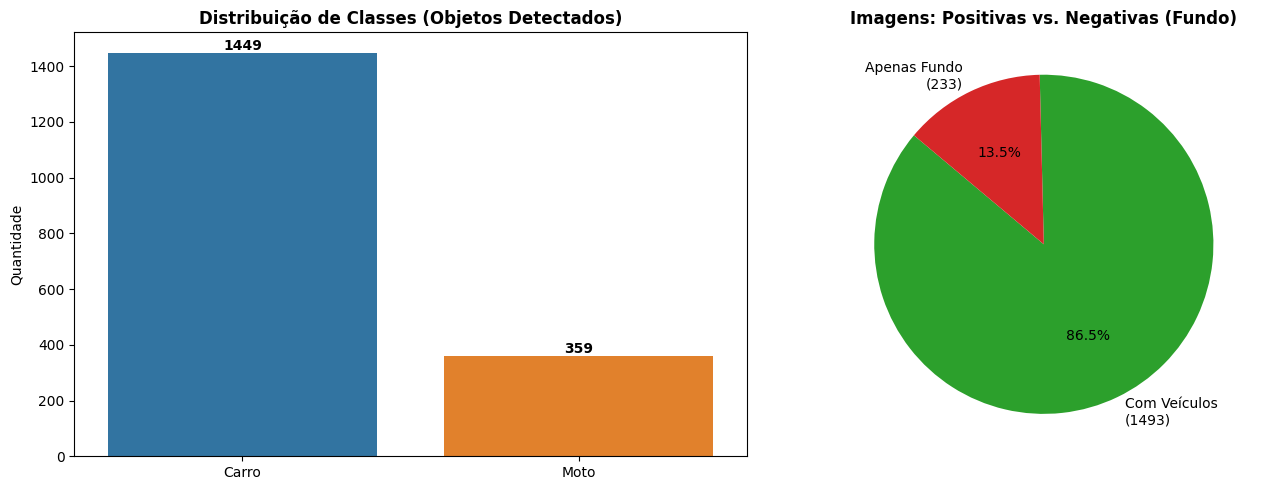

In [14]:
# Caminho do dataset
lbl_dir = Path(DATASET_ROOT) / 'train' / 'labels'

CLASS_NAMES = get_class_names()
class_counts = Counter()
empty_count = 0

# Abaixo estamos listando todos os arquivos que terminam com '.txt'
for lbl_file in lbl_dir.glob('*.txt'):
    # Se o arquivo estiver vazio, é uma imagem de fundo
    if lbl_file.stat().st_size == 0:
        empty_count += 1
        continue

    # Se tiver conteúdo, lê as classes
    with open(lbl_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5: # Formato bbox
                class_id = int(parts[0])
                class_counts[class_id] += 1
            elif len(parts) > 5: # Formato polígono (como descobrimos antes)
                class_id = int(parts[0])
                class_counts[class_id] += 1

# --- Visualização dos Dados ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição de Classes
names = [CLASS_NAMES.get(k, f'Classe {k}') for k in class_counts.keys()]
counts = list(class_counts.values())

sns.barplot(x=names, y=counts, palette=['#1f77b4', '#ff7f0e'], ax=axes[0])
axes[0].set_title('Distribuição de Classes (Objetos Detectados)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfico 2: Amostras Positivas vs Negativas
total_images = len(list(lbl_dir.glob('*.txt')))
positive_images = total_images - empty_count

labels_pie = [f'Com Veículos\n({positive_images})', f'Apenas Fundo\n({empty_count})']
colors_pie = ['#2ca02c', '#d62728']

axes[1].pie([positive_images, empty_count], labels=labels_pie, autopct='%1.1f%%',
            startangle=140, colors=colors_pie, textprops={'fontsize': 10})
axes[1].set_title('Imagens: Positivas vs. Negativas (Fundo)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:

print(f"\n📊 Resumo do Dataset de Treino:")
print(f"Total de imagens: {total_images}")
print(f"Imagens com veículos: {positive_images}")
print(f"Imagens de fundo (vazias): {empty_count}")
print(f"Total de objetos anotados: {sum(counts)}")


📊 Resumo do Dataset de Treino:
Total de imagens: 1726
Imagens com veículos: 1493
Imagens de fundo (vazias): 233
Total de objetos anotados: 1808


#### **Plotando imagens aleatórias**

In [16]:
def random_image_selection(split_name, n_images=5):
  """
  Função para selecionar imagens aleatórias do dataset
  podendo variar a quantidade mostrada.
  """
  img_dir = Path(DATASET_ROOT) / split_name / 'images'
  images = set([f.stem for f in img_dir.glob('*.jpg')])
  selected_images_paths = []

  for _ in range(n_images):
    random_image = random.choice(list(images))
    img_path = img_dir / f'{random_image}.jpg'
    selected_images_paths.append(img_path)

  return selected_images_paths

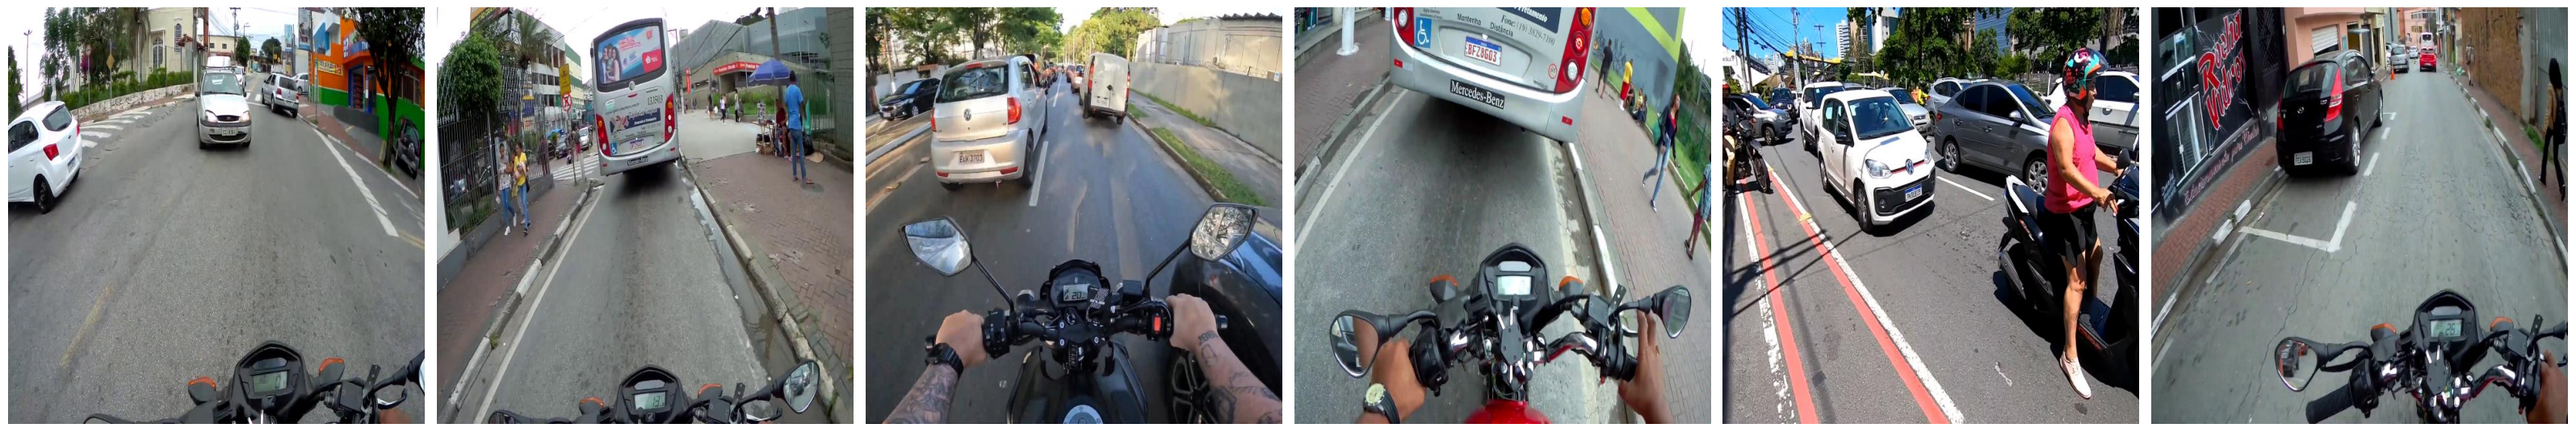

In [17]:
imgs = random_image_selection('train',6) # Listando as imagens

fig, axes = plt.subplots(1, 6, figsize=(32, 8))# Criando a moldura das imagens

for i, img in enumerate(imgs):
    s_img = cv2.imread(str(img))
    s_img = cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(s_img)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

#### **Plotando imagens com Bounding Boxes**

In [18]:
nomes_das_classes = get_class_names()
print(f"Classes carregadas!\n{nomes_das_classes}")

Classes carregadas!
{0: 'Carro', 1: 'Moto'}


In [19]:
def random_image_with_bounding_boxes(split_name, dataset_root=DATASET_ROOT):
    """
    Seleciona uma imagem aleatória e retorna seu caminho e anotações.
    Suporta tanto formato YOLO (bbox) quanto polígonos.

    Args:
        split_name (str): 'train', 'valid' ou 'test'
        dataset_root (str): Caminho raiz do dataset

    Returns:
        dict: Dicionário com 'image_path', 'annotations' e 'image'
    """

    # Definindo o caminho até os diretórios das imagens e labels
    img_dir = Path(dataset_root) / split_name / 'images'
    lbl_dir = Path(dataset_root) / split_name / 'labels'

    # Definindo um conjunto com os nomes das imagens e labels
    images = set([f.stem for f in img_dir.glob('*.jpg')])
    labels = set([f.stem for f in lbl_dir.glob('*.txt')])

    # Encontrando apenas as imagens com labels correspondente.
    valid_images = images.intersection(labels)

    # Selecionando uma imagem aleatória
    random_image = random.choice(list(valid_images))

    # Gerando a matriz de pixels da imagem aleatório escolhida
    img_path = img_dir / f'{random_image}.jpg'
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    annotations = []
    lbl_path = lbl_dir / f'{random_image}.txt'

    # Acessa o label da imagem aleatória
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()

            if len(parts) < 5:
                continue  # Não está no formato YOLO ou Polygon

            class_id = int(parts[0])

            # Verificando se é Polygon (>5)
            if len(parts) > 5:
              # Se estiver no formato Polygon precisamos puxar todos os valores
                x_coords = []
                y_coords = []

                # Vamos pegar todos os valores utilizando de range.
                for i in range(1, len(parts), 2): # Pulamos 0, que é classe id.
                    x = float(parts[i])
                    y = float(parts[i+1])
                    x_coords.append(x)
                    y_coords.append(y)

                # Agora que temos os valores precisamos encontrar o retângulo
                # Calcula o bbox mínimo que envolve todo o polígono
                x_min = min(x_coords)
                y_min = min(y_coords)
                x_max = max(x_coords)
                y_max = max(y_coords)

                # Calcular centro e largura/altura no formato YOLO
                x_center = (x_min + x_max) / 2
                y_center = (y_min + y_max) / 2
                width = x_max - x_min
                height = y_max - y_min

                annotations.append({
                    'class_id': class_id,
                    'x_center': x_center,
                    'y_center': y_center,
                    'width': width,
                    'height': height,
                    'format': 'polygon_converted'
                })

            else:
                # Formato YOLO padrão: class_id x_center y_center width height
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])

                annotations.append({
                    'class_id': class_id,
                    'x_center': x_center,
                    'y_center': y_center,
                    'width': width,
                    'height': height,
                    'format': 'bbox'
                })

    return {
        'image_path': img_path, # Caminho da imagem dentro da pasta
        'image': image, # Matriz de Pixels da imagem
        'annotations': annotations, # Dados no formato YOLO
        'split': split_name # Origem da Imagem
    }

In [20]:
def plot_random_images_with_bboxes(split_name='train', n_images=4, class_names=None):
    """
    Plota múltiplas imagens aleatórias com bounding boxes.
    """

    if class_names is None:
        class_names = get_class_names()

    fig, axes = plt.subplots(1, n_images, figsize=(16, 5))
    if n_images == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        # Imagem aleatório com Bounding Boxes garantido
        sample = random_image_with_bounding_boxes(split_name)

        image = sample['image']
        annotations = sample['annotations']
        img_height, img_width = image.shape[:2]

        ax.imshow(image)

        for ann in annotations:
            # Converter coordenadas normalizadas para absolutas
            x_min = (ann['x_center'] - ann['width']/2) * img_width
            y_min = (ann['y_center'] - ann['height']/2) * img_height
            width = ann['width'] * img_width
            height = ann['height'] * img_height

            # Obter cor e nome da classe
            class_id = ann['class_id']
            color = CLASS_COLORS.get(class_id)
            class_name = class_names.get(class_id, f'Class {class_id}')

            # Criar retângulo
            rect = patches.Rectangle(
                (x_min, y_min), width, height,
                linewidth=1, edgecolor=color, facecolor='none'
            )
            ax.add_patch(rect)


        ax.set_title(f"Amostra {i+1}", fontsize=10)
        ax.axis('off')

    plt.suptitle(f"Dataset - Split: {split_name.upper()}",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    plt.show()

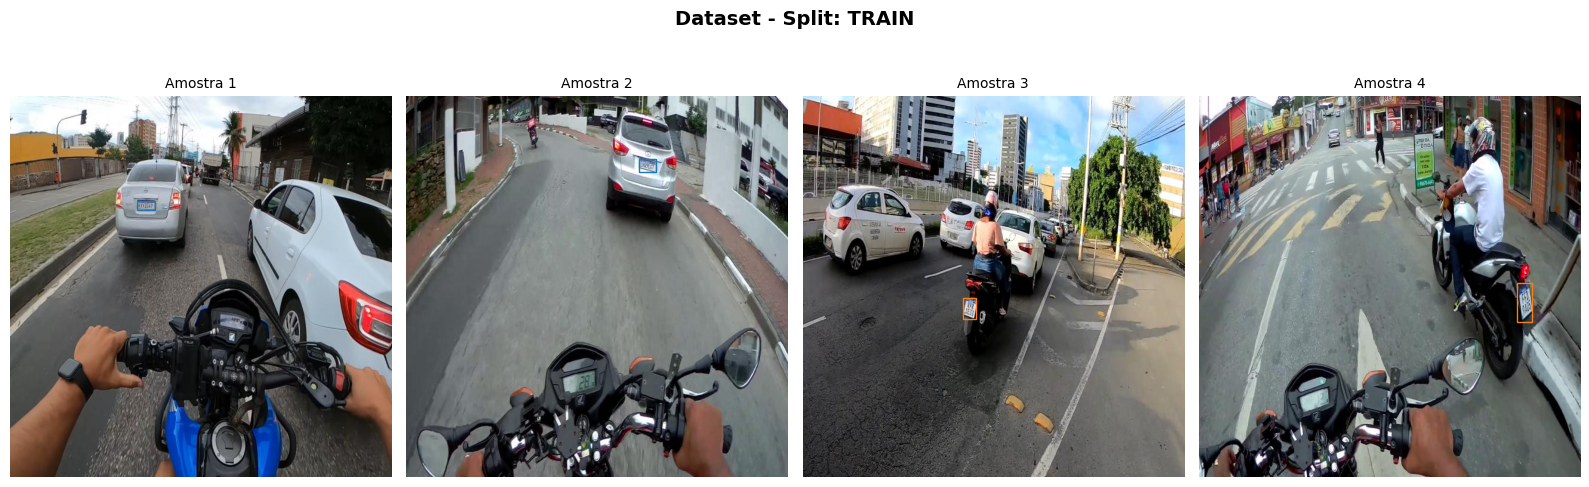

In [21]:
plot_random_images_with_bboxes('train',n_images=4)

#### **Verificando Brilho e Contraste das fotos**

In [22]:
def extrair_brilho_contraste(dataset_root=DATASET_ROOT, split_name= "train"):
  """
  Percorre o diretório de imagens e calcula a média de brilho
  e o desvio padrão (contraste) de cada imagem
  """
  img_dir = Path(dataset_root) / split_name / 'images'

  # Definindo um conjunto com os nomes das imagens e labels
  images = set([f.stem for f in img_dir.glob('*.jpg')])

  brilhos = []
  contrastes = []

  for img in images:
    img_path = img_dir / f'{img}.jpg'
    img = cv2.imread(str(img_path))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brilho = np.mean(gray)
    contraste = np.std(gray)

    brilhos.append(brilho)
    contrastes.append(contraste)

  return brilhos, contrastes


In [23]:
def plotar_histogramas(brilhos,constrates):
  """
  Plota os histogramas de distribuição de brilho e contraste.
  """
  sns.set_theme(style="whitegrid")
  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  # Histograma de Brilho
  sns.histplot(brilhos, kde=True, ax=axes[0], color='orange', bins=30)
  axes[0].set_title('Distribuição de Brilho Médio por Imagem')
  axes[0].set_xlabel('Brilho Médio (0 = Preto, 255 = Branco)')
  axes[0].set_ylabel('Quantidade de Imagens')
  axes[0].set_xlim(0, 255)

  # Histograma de Contraste
  sns.histplot(constrates, kde=True, ax=axes[1], color='purple', bins=30)
  axes[1].set_title('Distribuição de Contraste (Desvio Padrão) por Imagem')
  axes[1].set_xlabel('Contraste (Desvio Padrão dos Pixels)')
  axes[1].set_ylabel('Quantidade de Imagens')

  plt.tight_layout()
  plt.show()


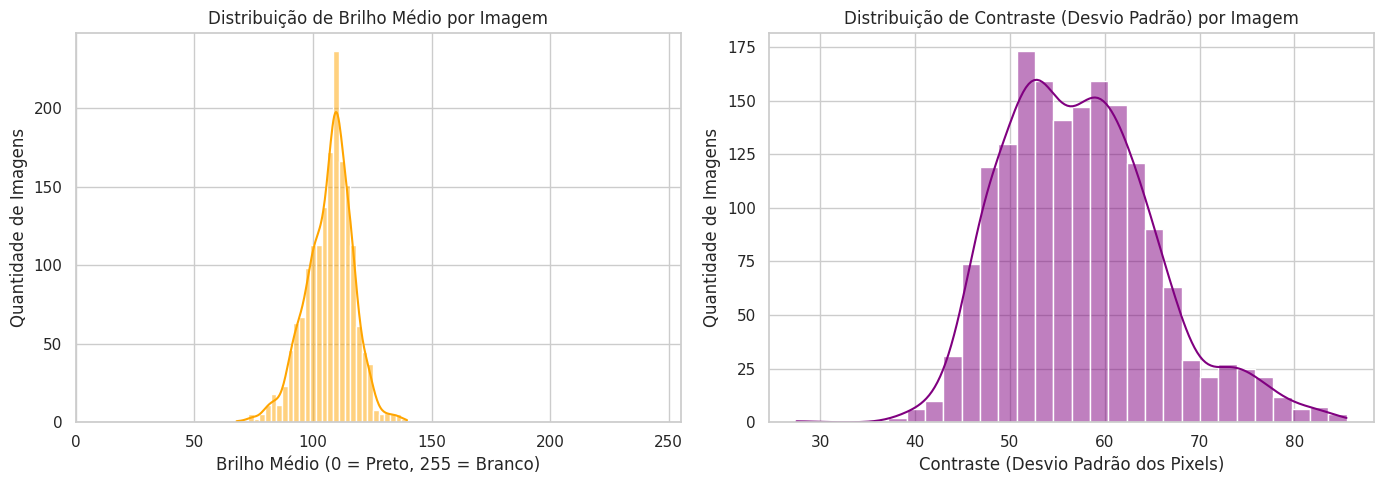

In [24]:
brilho,constrates = extrair_brilho_contraste()
plotar_histogramas(brilho,constrates)

#### **Analisando a distribuição espacial**

In [25]:
def analisando_distribuicao_espacial(dataset_root=DATASET_ROOT,split_name='train',img_width=640,img_height=640):
  """
  Lê rótulos YOLO e calcula os centroides e a grade de ocupação acumulada.
  """
  lbl_dir = Path(dataset_root) / split_name / 'labels'

  # Definindo um conjunto com os nomes das imagens e labels
  lbl_paths = list(lbl_dir.glob('*.txt'))

  centroides_x = []
  centroides_y = []
  grid_cobertura = np.zeros((img_height,img_width),dtype=np.float32)

  for lbl_path in lbl_paths:
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) >= 3 and (len(parts) - 1) % 2 == 0:
                    # Slicing limpo: pega x nas posições pares e y nas ímpares
                    coords = [float(p) for p in parts[1:]]
                    x_coords = coords[0::2]
                    y_coords = coords[1::2]

                    x_min, x_max = min(x_coords), max(x_coords)
                    y_min, y_max = min(y_coords), max(y_coords)

                    # Centroide da caixa que engloba o polígono
                    x_center = (x_min + x_max) / 2
                    y_center = (y_min + y_max) / 2

                    centroides_x.append(x_center)
                    centroides_y.append(y_center)

                    # Conversão direta de normalizado -> pixels
                    x1 = int(max(0, x_min * img_width))
                    y1 = int(max(0, y_min * img_height))
                    x2 = int(min(img_width, x_max * img_width))
                    y2 = int(min(img_height, y_max * img_height))

                    # Acumula na matriz de cobertura
                    grid_cobertura[y1:y2, x1:x2] += 1.0

  return centroides_x, centroides_y, grid_cobertura


In [26]:
def plotar_distribuicao_espacial(centroides_x, centroides_y, grid_cobertura):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 1. Densidade dos Centroides (KDE Plot)
    sns.kdeplot(
        x=centroides_x,
        y=centroides_y,
        ax=axes[0],
        cmap="magma",
        fill=True,
        thresh=0,
        levels=15
    )
    axes[0].set_title("Heatmap de Densidade dos Centroides $(c_x, c_y)$")
    axes[0].set_xlabel("Posição Horizontal Normalizada ($X$)")
    axes[0].set_ylabel("Posição Vertical Normalizada ($Y$)")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(1, 0)  # Inverte eixo Y para coincidir com a origem (0,0) no canto superior esquerdo da imagem
    axes[0].grid(True, linestyle="--", alpha=0.4)

    # 2. Ocupação Acumulada das Caixas (Occupancy Grid)
    im = axes[1].imshow(grid_cobertura, cmap='hot', interpolation='nearest')
    axes[1].set_title("Cobertura Acumulada das Bounding Boxes")
    axes[1].set_xlabel("Pixels ($X$)")
    axes[1].set_ylabel("Pixels ($Y$)")
    fig.colorbar(im, ax=axes[1], label="Quantidade de Sobreposições")

    plt.tight_layout()
    plt.show()

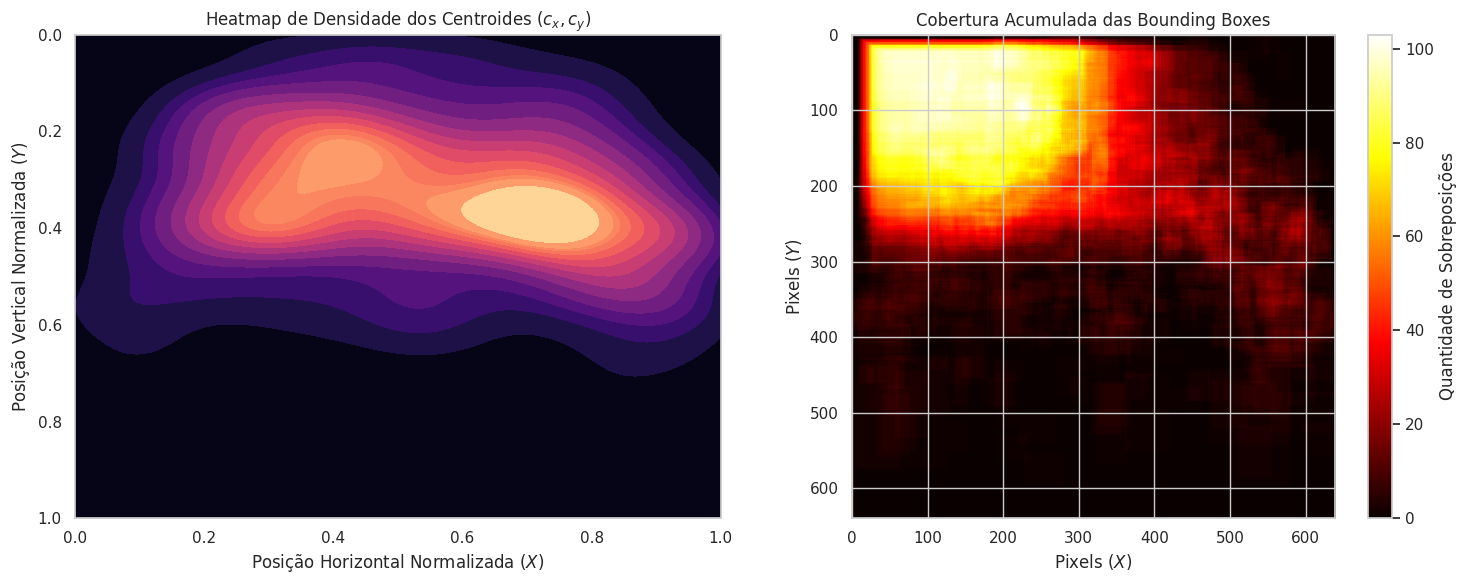

In [27]:
cx,cy,grid = analisando_distribuicao_espacial()
plotar_distribuicao_espacial(cx,cy,grid)

Note que o plot que realizamos mostrou que existe um vício espacial severo.

No primeiro plot, a esquerda, note que 100% dos centroides estão localizados na metade superior do frame. Já no segundo plot, a direita, temos uma concentração no quadrante superior esquerda e única área relevante para nosso modelo será dado entre o Y=0;300.


**E para resolver isso?**

Dado o contexto do dataset ser de Câmeras acopladas em motociclistas (no capacete, no peito ou no guidão) é necessário tomar cuidado para não distorcer a placa.

As técnicas mais apropriadas são de:
1. Translação Vertical e Horizontal (Random Shift, 15% a 20%)
2. Aumento de Escala/Zoom In (Random Scale/Crop, 10 a 30%)
3. Rotação (suave, 10 a 15 graus)

Outras estratégias são de ajustes nos hiperparâmetros do YOLO.

## 🧠 Etapa 4: Treinamento do Modelo (Deep Learning / YOLO)
*Desenvolvimento e otimização do modelo para reconhecimento e classificação de objetos.*
- **Seleção do Modelo:** Carregamento de um modelo pré-treinado (ex: YOLOv8n ou YOLOv8s) para *Transfer Learning*.
- **Configuração de Hiperparâmetros:** Definição de *epochs*, *batch size*, *image size* e técnicas de *Data Augmentation* (rotação, brilho, ruído) para aumentar a robustez do modelo em condições adversas de pedágio.
- **Execução do Treino:** Rodar o treinamento utilizando a GPU e salvar os *artifacts* (pesos finais e gráficos de perda) diretamente no Google Drive.

#### **Rodando baseline antes de tudo**

In [ ]:
model = YOLO('yolov8s.pt')

Sabemos o modelo, mas precisamos primeiro verificar o desempenho na versão baseline do modelo.

Sendo assim, podemos estabelecer um baseline do mAP!
Só após isso iremos aplicar as técnicas de Data Augmentation e ajustar a learning rate para ver o ganho de performance e evitando overfitting

In [ ]:
result= model.train(
    data="/content/placas_brasileiras-10/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project='/content/drive/MyDrive/FreeFlow_Vision_Pipeline/models',
    name='baseline_yolov8s',
    exist_ok=True,
    plots=True
    )

Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/placas_brasileiras-10/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolov8s, nbs=

**box_loss**: O erro na localização da caixa (onde está o objeto).


**cls_loss:** O erro na classificação (se é carro ou moto).


**mAP50 e mAP50-95**: As métricas de precisão. O mAP50 diz: "De 100 vezes que o modelo tentou achar o carro com uma sobreposição de 50% com a caixa real, quantas ele acertou?".

## 📊 Etapa 5: Avaliação e Otimização do Desempenho
*Validação rigorosa do modelo antes da integração ao pipeline.*
- **Métricas de Desempenho:** Geração e análise de mAP@50, mAP@50-95, Precisão e Recall.
- **Matriz de Confusão:** Identificação de classes que o modelo está confundindo (ex: classificar uma caminhonete como carro).
- **Teste de Inferência:** Execução do modelo em imagens de teste fora do dataset original para validar a generalização.

## 🔤 Etapa 6: Pipeline de OCR (Reconhecimento Óptico de Caracteres)
*Transformando a detecção visual em dados estruturados de texto.*
- **Recorte (Cropping):** Utilização das coordenadas da *bounding box* da "Placa" (detectada pelo YOLO) para recortar a região de interesse da imagem original.
- **Leitura do Texto:** Aplicação do modelo OCR (EasyOCR) na imagem recortada.
- **Pós-processamento:** Limpeza do texto extraído utilizando Expressões Regulares (Regex) para validar e padronizar o formato da placa (ex: padrão Mercosul ou antigo), descartando leituras com baixa confiança.

## 💾 Etapa 7: Banco de Dados e Montagem da Transação (Simulação OBO)
*Análise de algoritmos de montagem de transações, unindo Visão Computacional e SQL.*
- **Modelagem de Dados:** Criação de um banco de dados SQLite com tabelas relacionais: `capturas`, `deteccoes` e `transacoes_freeflow`.
- **Regras de Negócio:** Implementação de lógica para classificar o tipo de cobrança com base na classe do veículo detectado (ex: eixos, categoria).
- **Inserção e Consulta:** Gravação dos dados processados (timestamp, placa, categoria, valor) via SQL e realização de consultas analíticas para simular a auditoria das transações.
- *(Opcional/Avançado)*: Uso de um prompt de IA Generativa (LLM) para atuar como um "motor de regras", interpretando detecções ambíguas e sugerindo a classificação correta com base em descrições textuais.

## 🚀 Etapa 8: Documentação, MLOps e Próximos Passos
*Visão de ciclo de vida completo do modelo, indo além do notebook.*
- **Resumo dos Resultados:** Consolidação das métricas finais e lições aprendidas durante o desenvolvimento.
- **Plano de Produção (MLOps):** Descrição de como este notebook seria refatorado em um ambiente profissional:
  1. Modularização do código em scripts Python (`.py`).
  2. Criação de uma API REST (ex: FastAPI) para receber imagens em tempo real.
  3. Containerização da aplicação utilizando **Docker**.
  4. Deploy em ambiente **Linux** e orquestração em nuvem (AWS/GCP/Azure).
- **Conclusão:** Como esta solução evolui as regras de negócio e a confiabilidade do projeto Free Flow.